# Mock Exam: Student Productivity Dataset

You are given `ultimate_student_productivity_dataset_5000.csv` and must build a complete ML workflow.

## Rules
- Time limit: 90 minutes
- Use only `pandas`, `numpy`, `matplotlib`, `seaborn`, and `scikit-learn`
- Show clear reasoning in markdown cells
- Do **not** use data leakage

## Exam Question

Build models to understand and predict student outcomes using this dataset.

### Part A — Data Understanding (15 marks)
1. Load the data and report shape, dtypes, and missing values.
2. Provide a concise summary of key numeric features.
3. Create 3 meaningful visualizations and state one insight from each.

### Part B — Regression (30 marks)
Target: `exam_score`
1. Prepare features and split train/test (80/20, `random_state=42`).
2. Build a preprocessing + model pipeline (proper handling of numeric/categorical features).
3. Train **at least two** regressors and compare using MAE and R².
4. Select the better model and interpret top feature effects/importances.

### Part C — Classification (30 marks)
Create binary target: `high_performer = 1` if `exam_score >= 70`, else `0`.
1. Train **at least two** classifiers.
2. Evaluate with Accuracy, Precision, Recall, F1, and ROC-AUC.
3. Show confusion matrix for your best classifier and explain errors.

### Part D — Interpretation & Recommendations (25 marks)
1. Identify 3 controllable factors linked to better performance.
2. Recommend 3 practical interventions for students.
3. Briefly discuss one ethical or fairness concern in this analysis.

In [20]:
# Part A: Setup and data loading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

df = pd.read_csv('ultimate_student_productivity_dataset_5000.csv')
df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [ ]:
# Part A: Basic checks (GUIDED — no answers shown)

data_path = "ultimate_student_productivity_dataset_5000.csv"
target_col = "exam_score"
feature_cols = ["study_hours", "social_media_hours", "sleep_hours", "mental_health_score"]

df = pd.read_csv(data_path)
df.columns = [c.strip() for c in df.columns]

# 1) Shape + preview
print("Shape:", df.shape)
display(df.head())

# 2) Data types
display(df.dtypes.rename("dtype"))

# 3) Missing values (count + %)
missing_tbl = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)
display(missing_tbl[missing_tbl["missing_count"] > 0])

# 4) Numeric summary
num_cols = df.select_dtypes(include="number").columns
display(df[num_cols].describe().T)

# 5) Categorical summary
cat_cols = df.select_dtypes(exclude="number").columns
for c in cat_cols:
    print(f"\nValue counts for: {c}")
    display(df[c].value_counts(dropna=False).head(10))

# 6) Duplicates check
print("\nDuplicate rows:", df.duplicated().sum())

# 7) Quick sanity checks for hour-based features (no interpretation here)
hour_cols = [c for c in df.columns if "hours" in c]
for c in hour_cols:
    neg_count = (df[c] < 0).sum() if pd.api.types.is_numeric_dtype(df[c]) else "N/A"
    print(f"{c}: negatives = {neg_count}")

# TODO (markdown, not code): Write a 3-5 line summary of what you observed above.

Shape: (5000, 21)


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


student_id                int64
age                       int64
gender                      str
academic_level              str
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes          int64
caffeine_intake_mg        int64
part_time_job             int64
upcoming_deadline         int64
internet_quality            str
mental_health_score       int64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
Name: dtype, dtype: object

,missing_count,missing_pct


,count,mean,std,min,25%,50%,75%,max
student_id,5000.0,2500.500000,1443.520003,1.0,1250.7500,2500.50,3750.2500,5000.00
age,5000.0,20.520400,2.870406,16.0,18.0000,20.00,23.0000,25.00
study_hours,5000.0,4.539594,1.821665,0.0,3.2500,4.53,5.7600,11.84
self_study_hours,5000.0,2.478734,1.177990,0.0,1.6600,2.48,3.2900,7.41
online_classes_hours,5000.0,2.011984,0.983906,0.0,1.3200,2.01,2.6900,6.00
social_media_hours,5000.0,2.998086,1.467949,0.0,1.9900,2.98,4.0300,8.28
gaming_hours,5000.0,1.564514,1.110807,0.0,0.6700,1.49,2.3400,5.64
sleep_hours,5000.0,7.016492,1.163692,4.0,6.2375,7.01,7.8100,10.00
screen_time_hours,5000.0,6.979588,2.486214,1.0,5.2800,6.95,8.7100,15.30
exercise_minutes,5000.0,74.535600,42.932293,0.0,37.0000,75.00,112.0000,149.00


...


Value counts for: academic_level


academic_level
Postgraduate     1687
High School      1672
Undergraduate    1641
Name: count, dtype: int64


Value counts for: internet_quality


internet_quality
Good       1722
Poor       1640
Average    1638
Name: count, dtype: int64


Duplicate rows: 0
study_hours: negatives = 0
self_study_hours: negatives = 0
online_classes_hours: negatives = 0
social_media_hours: negatives = 0
gaming_hours: negatives = 0
sleep_hours: negatives = 0
screen_time_hours: negatives = 0


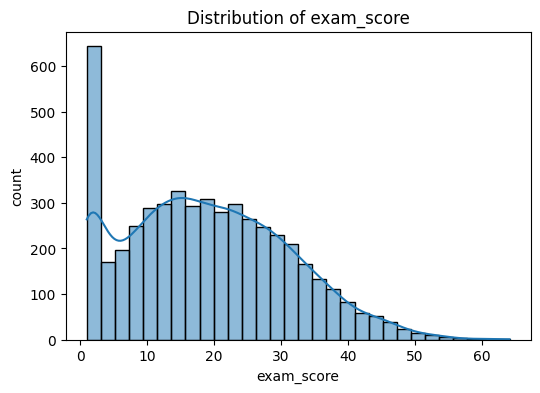

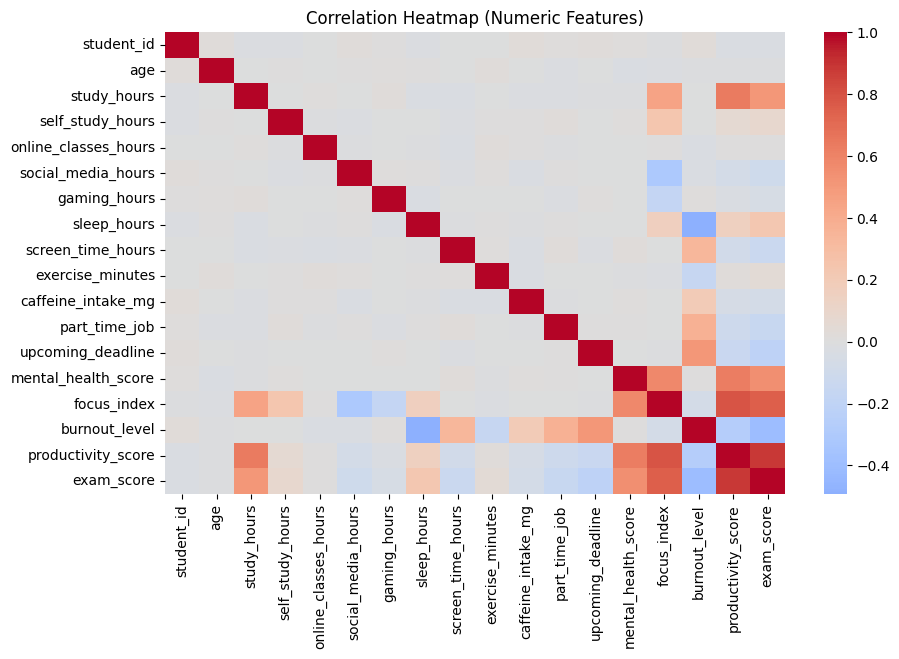

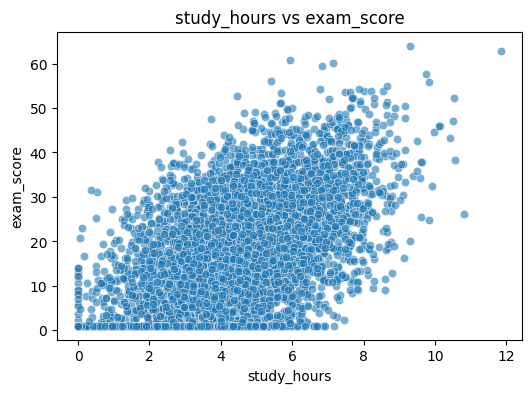

In [ ]:
# Part A: Visualizations

# Plot 1: Target distribution
plt.figure(figsize=(6,4))
sns.histplot(df[target_col], kde=True)
plt.title("Distribution of exam_score")
plt.xlabel("exam_score")
plt.ylabel("count")
plt.show()

# Plot 2: Correlation heatmap for numeric columns
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

# Plot 3: Relationship between one key feature and target
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="study_hours", y=target_col, alpha=0.6)
plt.title("study_hours vs exam_score")
plt.xlabel("study_hours")
plt.ylabel("exam_score")
plt.show()

# TODO (markdown, not code):
# - Add one insight below each plot in a markdown cell.
# - Keep each insight to 1-2 sentences.
# - Describe pattern, not cause (avoid causal claims).

In [23]:
# Part B: Regression setup
# TODO: Define X, y with y = exam_score
# TODO: Split data
# TODO: Build preprocessing for numeric/categorical columns

In [24]:
# Part B: Train and evaluate at least 2 regressors
# TODO: Model 1
# TODO: Model 2
# TODO: Compare MAE and R2 on test set

In [25]:
# Part C: Create binary target
df_cls = df.copy()
df_cls['high_performer'] = (df_cls['exam_score'] >= 70).astype(int)
# TODO: Confirm class balance
df_cls['high_performer'].value_counts(normalize=True)

high_performer
0    1.0
Name: proportion, dtype: float64

In [26]:
# Part C: Train and evaluate at least 2 classifiers
# TODO: Define X, y for classification
# TODO: Train models and compare Accuracy, Precision, Recall, F1, ROC-AUC

In [27]:
# Part C: Confusion matrix for best classifier
# TODO: Plot confusion matrix and explain FP/FN patterns

## Part D — Written Response (answer in this cell)
- 3 controllable factors linked to better outcomes:
- 3 recommended interventions:
- 1 ethical/fairness concern: